<font size="6">Calling libraries</font>

In [1]:
import torch
import os
import torch.nn as nn
from torchvision import transforms , datasets
from torch.utils.data import DataLoader , random_split
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from torchview import draw_graph
os.environ["PATH"] += os.pathsep + r"C:\\Program Files\\Graphviz\\bin"

<font size="6">The model code</font>

In [2]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1),
        )
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, X):
        x = self.features(X)
        x = self.flatten(x)
        return self.classifier(x)

<font size="6">Loading the model</font>

In [4]:
model = CNN(120)
model.load_state_dict( torch.load("..\\Model\\model1.pth" , map_location=torch.device('cpu') , weights_only=False ) )



<All keys matched successfully>

<font size="6">Showing the ready params</font>

In [5]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Layer: {name} | Shape: {param.data.shape}")
        print(param.data)

Layer: features.0.weight | Shape: torch.Size([32, 3, 3, 3])
tensor([[[[-2.9465e-01, -1.1647e-01, -5.1255e-01],
          [-2.7446e-01, -3.9427e-01, -1.6995e-01],
          [-2.4110e-01, -6.4557e-01, -3.4303e-01]],

         [[ 5.0672e-02,  4.2117e-01, -1.1857e-01],
          [-3.1364e-01,  5.1295e-02,  3.1707e-01],
          [-3.7814e-01, -5.5506e-01, -1.2075e-01]],

         [[ 5.8075e-01,  1.0312e+00,  3.6200e-01],
          [ 1.7132e-01,  4.4448e-01,  7.9301e-01],
          [-3.5203e-01,  4.7849e-02,  4.0458e-01]]],


        [[[ 2.9971e-01, -5.4681e-02, -1.9811e-01],
          [ 6.3613e-01, -6.1457e-01, -3.6125e-01],
          [ 7.4980e-01,  1.8860e-01, -2.4158e-01]],

         [[-4.7085e-01, -3.6676e-01, -4.4716e-02],
          [-1.7212e-01, -8.4812e-01, -3.2821e-01],
          [ 2.7672e-01,  2.3234e-01,  3.3669e-01]],

         [[-7.5404e-01,  1.3499e-02,  5.0460e-01],
          [-2.2852e-01, -2.7380e-01,  2.7047e-01],
          [ 2.8305e-01,  2.6631e-01,  6.7100e-01]]],


      

<font size="6">A simple graph for it</font>

In [ ]:
model_graph = draw_graph(
    model, 
    input_size=(1, 3, 224, 224), 
    expand_nested=True, 
    graph_name="Custom_CNN",
    roll=True          
)


model_graph.visual_graph.render("custom_cnn_architecture", format="png", cleanup=True)

print("Success! Your cool network graphic has been saved as 'custom_cnn_architecture.png'")


(process:3196): Pango-WARNING **: 20:04:38.591: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Success! Your cool network graphic has been saved as 'custom_cnn_architecture.png'


<font size="6">The demo code</font>


<font size="6">Note:"don't forget to read the comment inside"</font>

1. n02085620-Chihuahua: 79.94%
2. n02086079-Pekinese: 15.88%
3. n02099712-Labrador_retriever: 2.73%


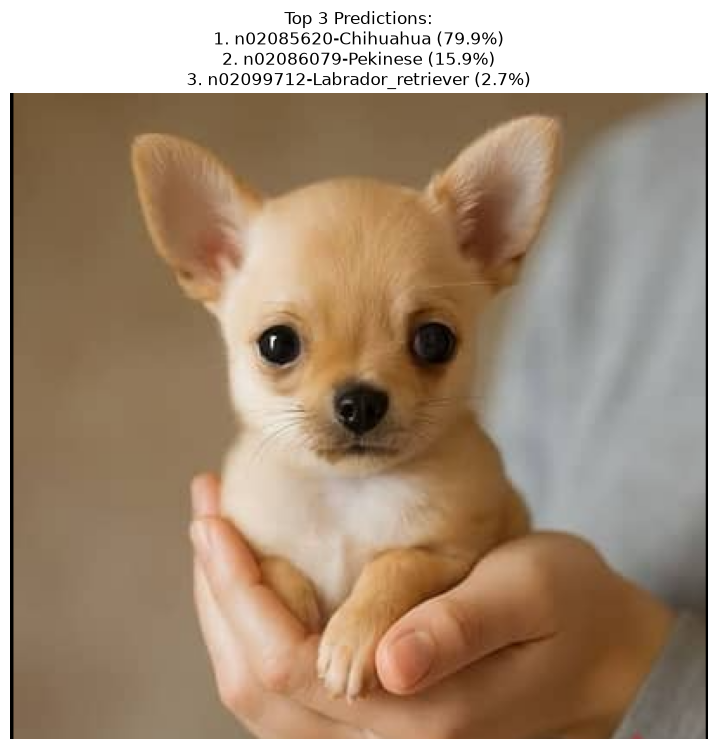

In [8]:
from PIL import Image
import torchvision.transforms as transforms
from torchvision import datasets
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F


class_names = datasets.ImageFolder(root="..\\assets\\one example of each dog").classes


img = Image.open('..\\Data\\Screenshot 2026-08-25 210832.png').convert('RGB') #change the directory of the image

preprocess = transforms.Compose([
    transforms.Resize((244, 244)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

model.eval()
with torch.no_grad():
    device = next(model.parameters()).device
    logit = model(input_tensor.to(device))
    
    probabilities = F.softmax(logit, dim=1)
    top3_prob, top3_indices = torch.topk(probabilities, k=3, dim=1)
    
   
    top3_indices = top3_indices.squeeze(0).tolist()
    top3_prob = top3_prob.squeeze(0).tolist()


title_text = "Top 3 Predictions:\n"
for i in range(3):
    label = class_names[top3_indices[i]]
    confidence = top3_prob[i] * 100
    print(f"{i+1}. {label}: {confidence:.2f}%")
    title_text += f"{i+1}. {label} ({confidence:.1f}%)\n"


fig = plt.figure(figsize=(9, 9))
plt.imshow(img)
plt.title(title_text.strip(), fontsize=12)
plt.axis('off') 
plt.show()